
 PARKINSON'S DISEASE DETECTION USING MACHINE LEARNING
 Algorithms Used: Decision Tree | SVM
 Dataset: UCI Parkinson's Dataset



─────────────────────────────────────────────────────────────
## SECTION 1 ── IMPORT LIBRARIES



In [21]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, r2_score,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)
from IPython.display import display





## SECTION 2 ── DATA COLLECTION



In [22]:
print("=" * 60)
print(" STEP 1: DATA COLLECTION")
print("=" * 60)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'

print("Downloading dataset from UCI repository...")
url_content = requests.get(url).content
with open('data.csv', 'wb') as f:
    f.write(url_content)

df = pd.read_csv('data.csv')
print(f"Dataset downloaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")




 STEP 1: DATA COLLECTION
Dataset downloaded successfully!
Shape: 195 rows × 24 columns



─────────────────────────────────────────────────────────────
SECTION 3 ── DATA PREPROCESSING
─────────────────────────────────────────────────────────────
Steps:
 ① Drop the 'name' column  — it's just a patient identifier,
   not a useful feature for ML.
 ② Check for duplicate rows — duplicates can bias the model.
 ③ Check for missing values — missing data must be handled.
 ④ Convert 'status' to uint8 — saves memory (only 0 or 1).
─────────────────────────────────────────────────────────────


In [23]:
## DATA PREPROCESSING

In [24]:
print("=" * 60)
print(" STEP 2: DATA PREPROCESSING")
print("=" * 60)

# ① Drop the name column (not a feature)
df.drop(['name'], axis=1, inplace=True)
print(f"After dropping 'name' column → {df.shape[1]} features remain")

# ② Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")  # Should be 0

# ③ Check for missing values
print(f"Missing values per column:\n{df.isna().sum().to_string()}\n")

# ④ Optimize memory: status is 0 or 1 → use uint8 instead of int64
df['status'] = df['status'].astype('uint8')

print("Basic Statistics:")
print(df.describe().round(2))




 STEP 2: DATA PREPROCESSING
After dropping 'name' column → 23 features remain
Duplicate rows: 0
Missing values per column:
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0

Basic Statistics:
       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count       195.00        195.00        195.00          195.00   
mean        154.23        197.10        116.32            0.01   
std          41.39         91.49         43.52            0.00   
min          88.33        102.14         65.48            0.00   
25%         117.57    

─────────────────────────────────────────────────────────────
## SECTION 4 ── EXPLORATORY DATA ANALYSIS (EDA)




 STEP 3: EXPLORATORY DATA ANALYSIS


C:\Users\PMYLS\AppData\Local\Temp\ipykernel_7840\3021827887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette='Set2')


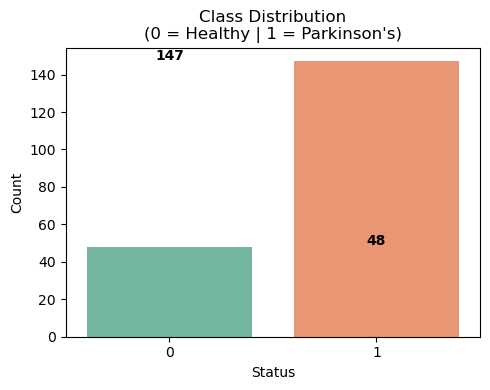

Class counts → Parkinson's (1): 147 | Healthy (0): 48


In [25]:
print("\n" + "=" * 60)
print(" STEP 3: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ── Class Distribution ──────────────────────────────────────
plt.figure(figsize=(5, 4))
counts = df['status'].value_counts()
sns.countplot(x='status', data=df, palette='Set2')
plt.title("Class Distribution\n(0 = Healthy | 1 = Parkinson's)")
plt.xlabel("Status"); plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=100)
plt.show()
print(f"Class counts → Parkinson's (1): {counts[1]} | Healthy (0): {counts[0]}")


⚠️ VIVA NOTE: The dataset is IMBALANCED → more Parkinson's samples.
   This is why we need SMOTE to balance it before training.


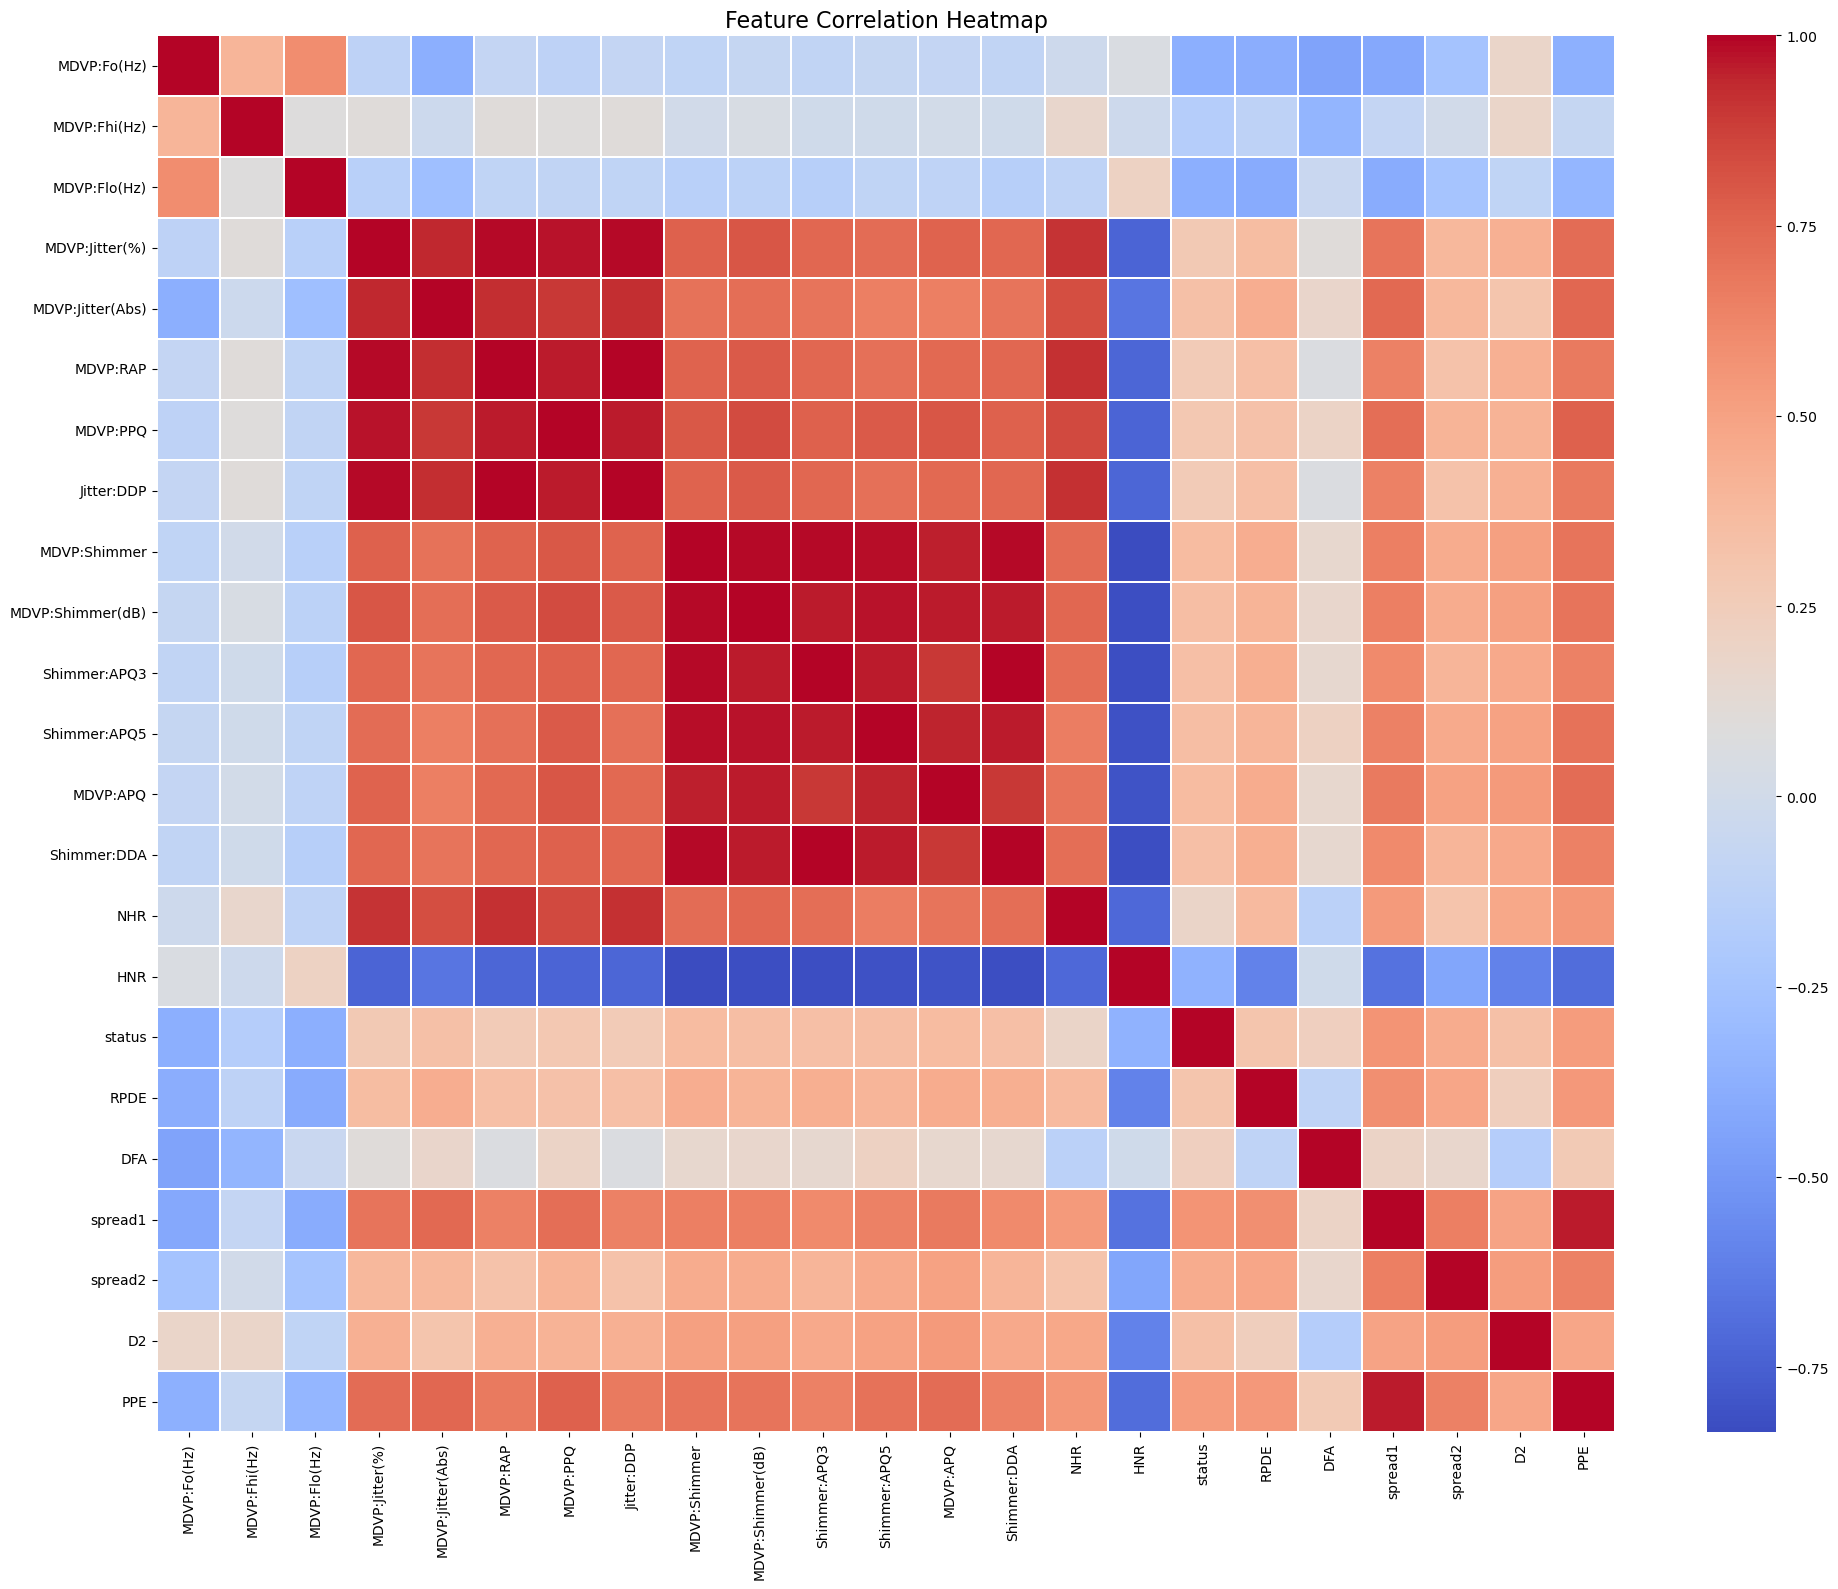

Correlation heatmap saved. Many features are highly correlated (multi-collinearity).


In [26]:

# ── Correlation Heatmap ─────────────────────────────────────
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=100)
plt.show()
print("Correlation heatmap saved. Many features are highly correlated (multi-collinearity).")


─────────────────────────────────────────────────────────────
## SECTION 5 ── BALANCING THE DATASET WITH SMOTE
─────────────────────────────────────────────────────────────
SMOTE = Synthetic Minority Over-sampling Technique
It generates SYNTHETIC new samples for the minority class
by interpolating between existing minority samples.
This prevents the model from being biased towards majority class.
─────────────────────────────────────────────────────────────


In [27]:
print("\n" + "=" * 60)
print(" STEP 4: BALANCING DATASET WITH SMOTE")
print("=" * 60)

X = df.drop(['status'], axis=1)
y = df['status']

print(f"Before SMOTE → X: {X.shape}, y distribution: {dict(y.value_counts())}")

sm = SMOTE(random_state=300)
X, y = sm.fit_resample(X, y)

print(f"After  SMOTE → X: {X.shape}, y distribution: {dict(y.value_counts())}")
# ⚠️ VIVA NOTE: After SMOTE both classes have equal samples → balanced dataset.





 STEP 4: BALANCING DATASET WITH SMOTE
Before SMOTE → X: (195, 22), y distribution: {1: 147, 0: 48}
After  SMOTE → X: (294, 22), y distribution: {1: 147, 0: 147}


─────────────────────────────────────────────────────────────
## SECTION 6 ── FEATURE SCALING (NORMALIZATION)
─────────────────────────────────────────────────────────────
MinMaxScaler rescales all features to range [-1, 1].
WHY? SVM is DISTANCE-BASED → if features are on different
scales, larger-value features dominate the decision boundary.
Decision Tree is NOT affected by scaling (it uses thresholds)
but we scale for both to keep preprocessing consistent.
─────────────────────────────────────────────────────────────


In [28]:
print("\n" + "=" * 60)
print(" STEP 5: FEATURE SCALING")
print("=" * 60)

scaler = MinMaxScaler((-1, 1))
X_scaled = scaler.fit_transform(X)
print("Features scaled to range [-1, 1] using MinMaxScaler.")
# ⚠️ VIVA NOTE: Always fit the scaler on training data ONLY to prevent data leakage.





 STEP 5: FEATURE SCALING
Features scaled to range [-1, 1] using MinMaxScaler.


─────────────────────────────────────────────────────────────
## SECTION 7 ── TRAIN-TEST SPLIT
─────────────────────────────────────────────────────────────
We split data: 80% for training, 20% for testing.
random_state=20 ensures reproducibility.
Stratify would ensure balanced split but since we used SMOTE
it's already balanced.
─────────────────────────────────────────────────────────────


In [29]:
print("\n" + "=" * 60)
print(" STEP 6: TRAIN-TEST SPLIT (80-20)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=20
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")



 STEP 6: TRAIN-TEST SPLIT (80-20)
Training samples : 235
Testing samples  : 59


─────────────────────────────────────────────────────────────
SECTION 8 ── ALGORITHM 1: DECISION TREE CLASSIFIER
─────────────────────────────────────────────────────────────
HOW DECISION TREE WORKS:
 • It splits the data at each node based on a feature threshold.
 • At each split it chooses the feature that gives the best
   separation (measured by Gini Impurity or Entropy/Info Gain).
 • It keeps splitting until leaves are pure or max_depth reached.
 • GINI: measures impurity = 1 - Σ(p_i²)
 • ENTROPY: measures disorder = -Σ(p_i × log₂(p_i))

ADVANTAGES:
 ✓ Easy to understand and visualize
 ✓ No need for feature scaling
 ✓ Handles both numerical and categorical data

DISADVANTAGES:
 ✗ Prone to overfitting (grows too deep)
 ✗ Sensitive to small changes in data (high variance)
─────────────────────────────────────────────────────────────


In [30]:
print("\n" + "=" * 60)
print(" ALGORITHM 1: DECISION TREE CLASSIFIER")
print("=" * 60)

# ── Step 8a: Base Decision Tree (no tuning) ─────────────────
print("\n[8a] Training base Decision Tree...")
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
pred_dt_base = dt_base.predict(X_test)
print(f"Base DT Accuracy: {accuracy_score(y_test, pred_dt_base)*100:.2f}%")




 ALGORITHM 1: DECISION TREE CLASSIFIER

[8a] Training base Decision Tree...
Base DT Accuracy: 89.83%


## Step 8b: Hyperparameter Tuning with GridSearchCV ────────
GridSearchCV tries ALL combinations of given parameters
and uses 5-Fold Cross Validation to find the best set.



[8b] Running GridSearchCV for Decision Tree...


C:\Users\PMYLS\anaconda\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best DT Parameters: {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'sqrt', 'random_state': 120}

[8c] Training optimized Decision Tree with best parameters...

── Decision Tree Classification Report ──
                 precision    recall  f1-score   support

    Healthy (0)       0.91      0.97      0.94        33
Parkinson's (1)       0.96      0.88      0.92        26

       accuracy                           0.93        59
      macro avg       0.94      0.93      0.93        59
   weighted avg       0.93      0.93      0.93        59



Text(0.5, 1.0, 'Confusion Matrix — Decision Tree')

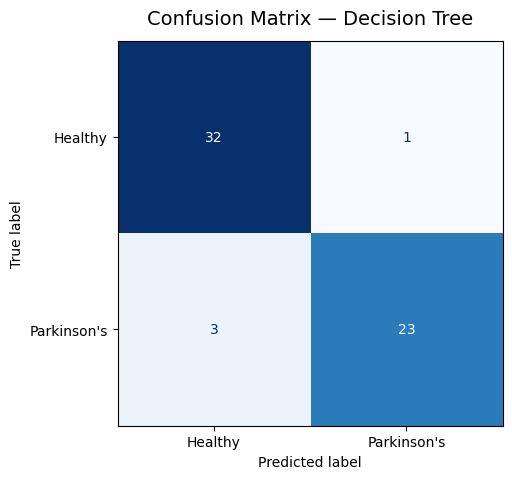

In [31]:
print("\n[8b] Running GridSearchCV for Decision Tree...")
param_grid_dt = {
    'max_features': ['sqrt', 'log2'],       # How many features to consider per split
    'max_depth': range(1, 10),               # Maximum depth of the tree
    'random_state': range(30, 210, 30),      # For reproducibility
    'criterion': ['gini', 'entropy']         # Splitting criterion
}
cv_dt = GridSearchCV(estimator=DecisionTreeClassifier(),
                     param_grid=param_grid_dt, cv=5, n_jobs=-1)
cv_dt.fit(X_train, y_train)
print(f"Best DT Parameters: {cv_dt.best_params_}")

# ── Step 8c: Train Optimized Decision Tree ──────────────────
print("\n[8c] Training optimized Decision Tree with best parameters...")
best_dt_params = cv_dt.best_params_
dt_model = DecisionTreeClassifier(**best_dt_params)
dt_model.fit(X_train, y_train)
pred_dt = dt_model.predict(X_test)

print("\n── Decision Tree Classification Report ──")
print(classification_report(y_test, pred_dt,
      target_names=["Healthy (0)", "Parkinson's (1)"]))

# ── Step 8d: Decision Tree Confusion Matrix ─────────────────
cm_dt = confusion_matrix(y_test, pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                               display_labels=["Healthy", "Parkinson's"])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
ax.set_title("Confusion Matrix — Decision Tree", fontsize=14, pad=12)


<Figure size 640x480 with 0 Axes>

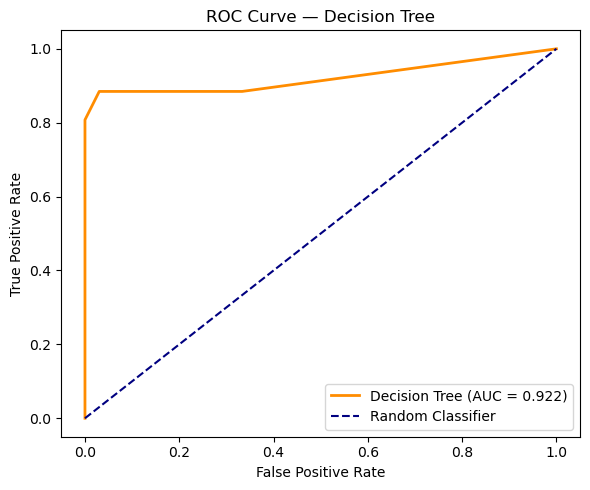

In [32]:
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=100)
plt.show()

# ── Step 8e: Decision Tree ROC Curve ────────────────────────
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2,
         label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('dt_roc_curve.png', dpi=100)
plt.show()


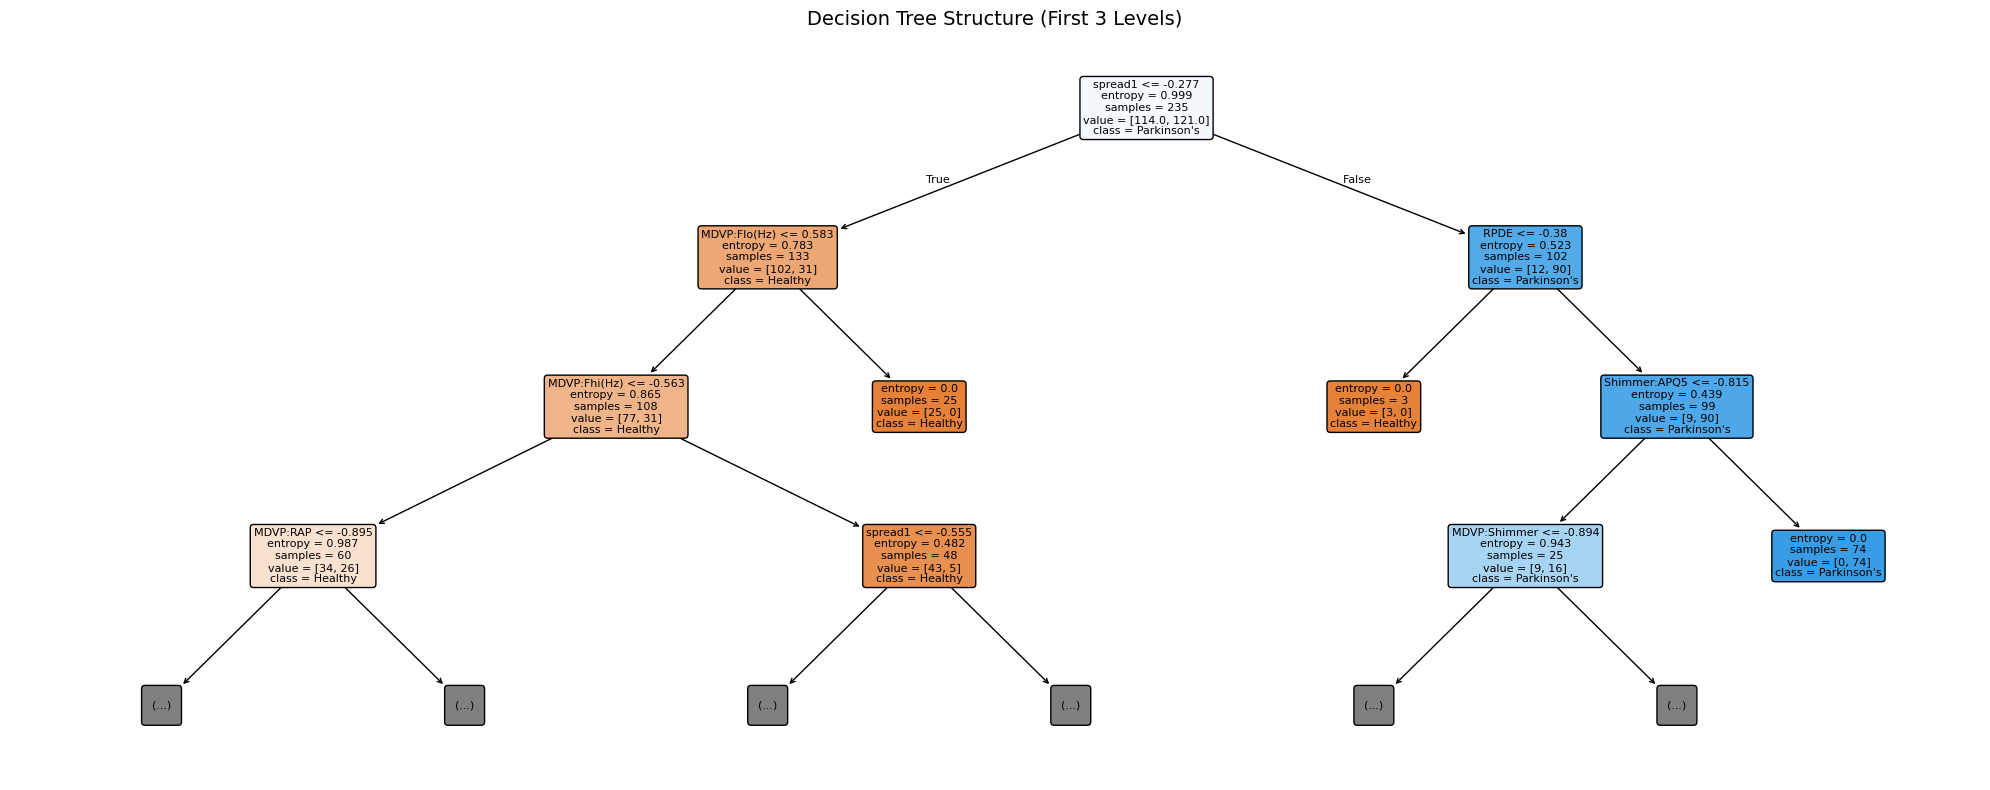


Decision Tree 5-Fold CV Accuracy: 84.39% ± 8.24%


In [33]:

# ── Step 8f: Decision Tree Visualization (first 3 levels) ───
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=list(X.columns),
          class_names=["Healthy", "Parkinson's"],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Decision Tree Structure (First 3 Levels)", fontsize=14)
plt.tight_layout()
plt.savefig('dt_tree_plot.png', dpi=100)
plt.show()

# ── Step 8g: Cross-Validation Score for Decision Tree ───────
cv_scores_dt = cross_val_score(dt_model, X_scaled, y, cv=5, scoring='accuracy')
print(f"\nDecision Tree 5-Fold CV Accuracy: {cv_scores_dt.mean()*100:.2f}% ± {cv_scores_dt.std()*100:.2f}%")


⚠️ VIVA NOTE: Cross-validation gives a more reliable estimate of model
   performance than a single train/test split.


─────────────────────────────────────────────────────────────
## SECTION 9 ── ALGORITHM 2: SUPPORT VECTOR MACHINE (SVM)
─────────────────────────────────────────────────────────────
HOW SVM WORKS:
 • SVM finds the OPTIMAL HYPERPLANE that maximally separates
   the two classes.
 • The distance between the hyperplane and the nearest data
   points (support vectors) is called the MARGIN.
 • SVM maximizes this margin → better generalization.

KERNEL TRICK:
 • For non-linearly separable data, SVM maps features into
   a higher-dimensional space where they ARE separable.
 • 'rbf' (Radial Basis Function) kernel is most common.
 • 'linear' kernel works for linearly separable data.

KEY PARAMETERS:
 • C: Regularization — controls trade-off between margin
   width and classification errors.
   Large C → smaller margin, fewer errors (may overfit)
   Small C → larger margin, more errors (may underfit)
 • gamma: Controls influence of a single training example.
   Large gamma → tight fit (may overfit)
   Small gamma → smooth fit (may underfit)

ADVANTAGES:
 ✓ Very effective in high-dimensional spaces
 ✓ Works well when classes are clearly separable
 ✓ Memory efficient (uses only support vectors)

DISADVANTAGES:
 ✗ Slow on very large datasets
 ✗ Requires feature scaling
 ✗ Hard to interpret (black box)
─────────────────────────────────────────────────────────────



 ALGORITHM 2: SUPPORT VECTOR MACHINE (SVM)

[9a] Training base SVM with linear kernel...
Base SVM (Linear) Test Accuracy: 81.36%
Base SVM (Linear) Train Accuracy: 86.38%

[9b] Running GridSearchCV for SVM (this may take a moment)...
Best SVM Parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best SVM CV F1-Score: 0.9672

[9c] Training optimized SVM with best parameters...

── SVM Classification Report ──
                 precision    recall  f1-score   support

    Healthy (0)       0.94      1.00      0.97        33
Parkinson's (1)       1.00      0.92      0.96        26

       accuracy                           0.97        59
      macro avg       0.97      0.96      0.97        59
   weighted avg       0.97      0.97      0.97        59



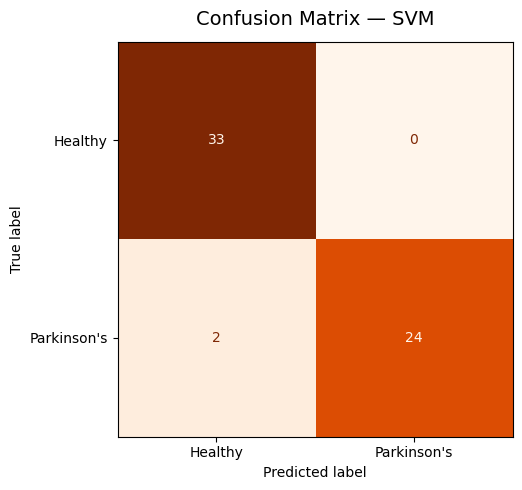

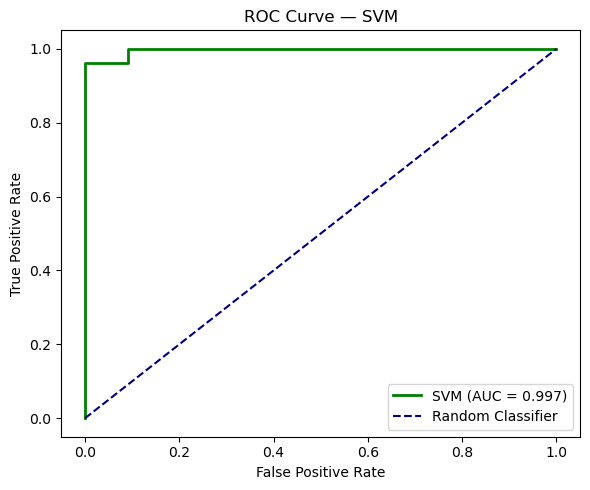


SVM 5-Fold CV Accuracy: 92.19% ± 3.94%


In [14]:
print("\n" + "=" * 60)
print(" ALGORITHM 2: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

# ── Step 9a: Base SVM (Linear Kernel) ───────────────────────
print("\n[9a] Training base SVM with linear kernel...")
svm_base = SVC(kernel='linear', random_state=42)
svm_base.fit(X_train, y_train)
y_pred_base_svm = svm_base.predict(X_test)
print(f"Base SVM (Linear) Test Accuracy: {accuracy_score(y_test, y_pred_base_svm)*100:.2f}%")

y_pred_base_train = svm_base.predict(X_train)
print(f"Base SVM (Linear) Train Accuracy: {accuracy_score(y_train, y_pred_base_train)*100:.2f}%")

# ── Step 9b: Hyperparameter Tuning with GridSearchCV ────────
print("\n[9b] Running GridSearchCV for SVM (this may take a moment)...")
param_grid_svm = {
    'kernel': ['linear', 'rbf', 'poly'],    # Type of kernel
    'C': [0.5, 1, 10, 100],                  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001]  # Kernel coefficient
}
grid_svm = GridSearchCV(SVC(probability=True),  # probability=True needed for ROC curve
                        param_grid_svm,
                        scoring='f1', cv=5, n_jobs=-1)
grid_svm.fit(X_train, y_train)
print(f"Best SVM Parameters: {grid_svm.best_params_}")
print(f"Best SVM CV F1-Score: {grid_svm.best_score_:.4f}")

# ── Step 9c: Train best SVM explicitly ──────────────────────
print("\n[9c] Training optimized SVM with best parameters...")
best = grid_svm.best_params_
svm_model = SVC(kernel=best['kernel'], C=best['C'],
                gamma=best['gamma'], probability=True, random_state=42)
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)

print("\n── SVM Classification Report ──")
print(classification_report(y_test, pred_svm,
      target_names=["Healthy (0)", "Parkinson's (1)"]))

# ── Step 9d: SVM Confusion Matrix ───────────────────────────
cm_svm = confusion_matrix(y_test, pred_svm)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                               display_labels=["Healthy", "Parkinson's"])
disp.plot(ax=ax, cmap=plt.cm.Oranges, colorbar=False)
ax.set_title("Confusion Matrix — SVM", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=100)
plt.show()

# ── Step 9e: SVM ROC Curve ──────────────────────────────────
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_svm, tpr_svm, color='green', lw=2,
         label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('svm_roc_curve.png', dpi=100)
plt.show()

# ── Step 9f: Cross-Validation Score for SVM ─────────────────
cv_scores_svm = cross_val_score(svm_model, X_scaled, y, cv=5, scoring='accuracy')
print(f"\nSVM 5-Fold CV Accuracy: {cv_scores_svm.mean()*100:.2f}% ± {cv_scores_svm.std()*100:.2f}%")




─────────────────────────────────────────────────────────────
## SECTION 10 ── COMPARISON: DECISION TREE vs SVM

We compare both models across 5 metrics:
 • Accuracy  : % of total correct predictions
 • Precision : Of all predicted positive, how many were right?
 • Recall    : Of all actual positive, how many did we catch?
 • F1-Score  : Harmonic mean of Precision & Recall
 • R2-Score  : Proportion of variance explained (0 to 1)




 SECTION 10: COMPARISON TABLE — DT vs SVM

   Metric  Decision Tree    SVM Winner
 Accuracy         0.9322 0.9661  SVM ⚡
Precision         0.9583 1.0000  SVM ⚡
   Recall         0.8846 0.9231  SVM ⚡
 F1-Score         0.9200 0.9600  SVM ⚡
 R2-Score         0.7249 0.8625  SVM ⚡
      AUC         0.9219 0.9965  SVM ⚡


C:\Users\PMYLS\AppData\Local\Temp\ipykernel_7840\908896616.py:62: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PMYLS\AppData\Local\Temp\ipykernel_7840\908896616.py:63: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
C:\Users\PMYLS\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


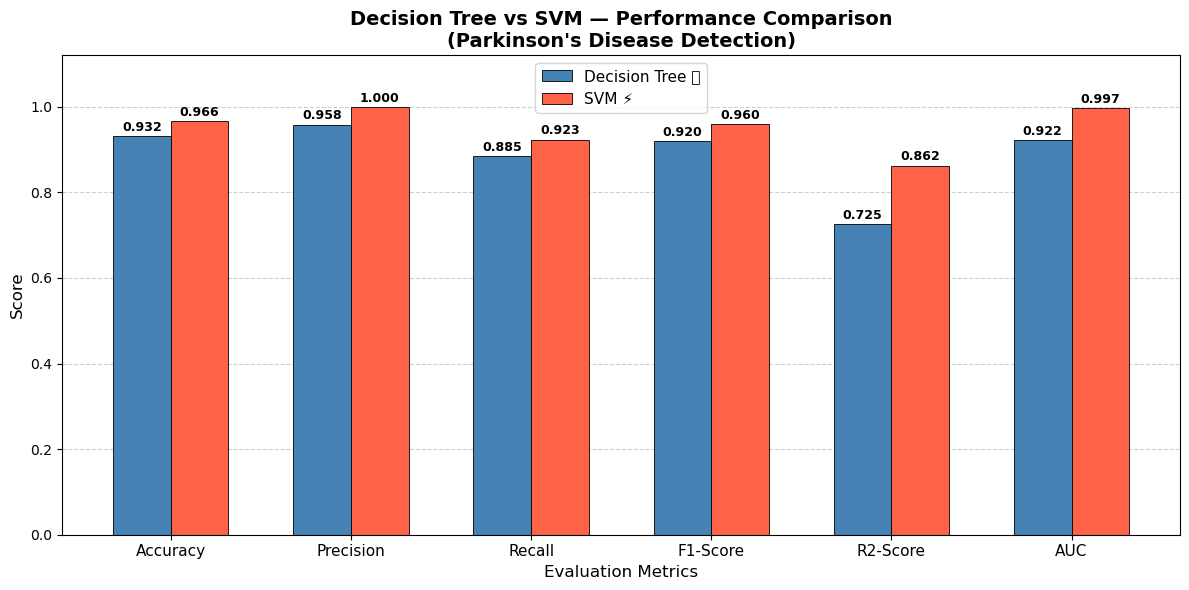


Comparison bar chart saved as 'comparison_chart.png'


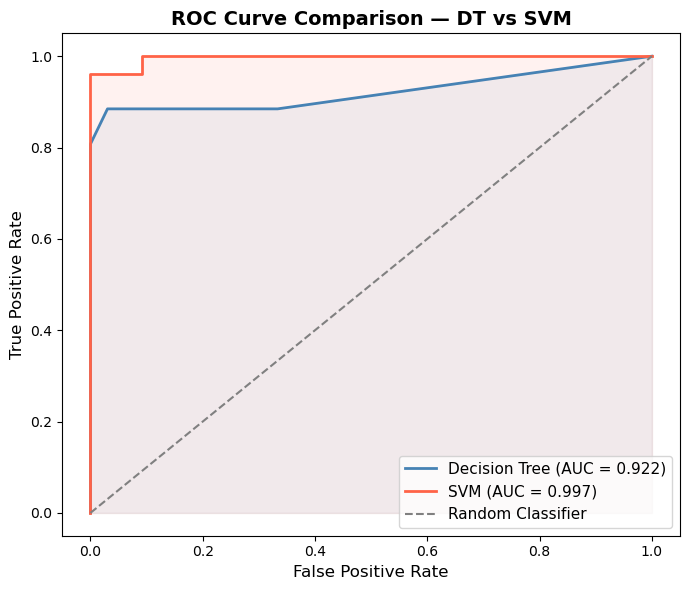

Combined ROC curve saved as 'combined_roc_curve.png'


In [15]:
print("\n" + "=" * 60)
print(" SECTION 10: COMPARISON TABLE — DT vs SVM")
print("=" * 60)

metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score", "R2-Score", "AUC"]

dt_scores = [
    accuracy_score(y_test, pred_dt),
    precision_score(y_test, pred_dt),
    recall_score(y_test, pred_dt),
    f1_score(y_test, pred_dt),
    r2_score(y_test, pred_dt),
    auc_dt
]
svm_scores = [
    accuracy_score(y_test, pred_svm),
    precision_score(y_test, pred_svm),
    recall_score(y_test, pred_svm),
    f1_score(y_test, pred_svm),
    r2_score(y_test, pred_svm),
    auc_svm
]

comparison_df = pd.DataFrame({
    'Metric'         : metrics_names,
    'Decision Tree'  : [round(s, 4) for s in dt_scores],
    'SVM'            : [round(s, 4) for s in svm_scores],
})
comparison_df['Winner'] = comparison_df.apply(
    lambda row: 'DT 🌳' if row['Decision Tree'] > row['SVM'] else 'SVM ⚡', axis=1
)
print("\n" + comparison_df.to_string(index=False))

# ── Comparison Bar Chart ─────────────────────────────────────
x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, dt_scores, width, label='Decision Tree 🌳',
               color='steelblue', edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM ⚡',
               color='tomato', edgecolor='black', linewidth=0.6)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel("Evaluation Metrics", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Decision Tree vs SVM — Performance Comparison\n(Parkinson's Disease Detection)",
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nComparison bar chart saved as 'comparison_chart.png'")

# ── Combined ROC Curve ───────────────────────────────────────
plt.figure(figsize=(7, 6))
plt.plot(fpr_dt, tpr_dt, color='steelblue', lw=2,
         label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_svm, tpr_svm, color='tomato', lw=2,
         label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr_dt, tpr_dt, alpha=0.08, color='steelblue')
plt.fill_between(fpr_svm, tpr_svm, alpha=0.08, color='tomato')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison — DT vs SVM", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('combined_roc_curve.png', dpi=150)
plt.show()
print("Combined ROC curve saved as 'combined_roc_curve.png'")




─────────────────────────────────────────────────────────────
## SECTION 11 ── FINAL SUMMARY



In [36]:

print(" FINAL SUMMARY")

print(f"  Decision Tree Accuracy : {dt_scores[0]*100:.2f}%")
print(f"  SVM Accuracy           : {svm_scores[0]*100:.2f}%")
print(f"  Decision Tree AUC      : {auc_dt:.4f}")
print(f"  SVM AUC                : {auc_svm:.4f}")
print()
winner = "SVM" if svm_scores[0] >= dt_scores[0] else "Decision Tree"
print(f"   Better Overall Model : {winner}")
print()



 FINAL SUMMARY
  Decision Tree Accuracy : 93.22%
  SVM Accuracy           : 96.61%
  Decision Tree AUC      : 0.9219
  SVM AUC                : 0.9965

   Better Overall Model : SVM

